# 01 — Demand models

Reproduce a Hursh–Silberberg demand curve from synthetic data, visualise Pmax/Omax, and compare the original log-space form against the Koffarnus exponentiated form. All model code lives in `edu.models.demand`; this notebook only orchestrates and plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from edu.models.demand import HurshSilberberg, Koffarnus

rng = np.random.default_rng(2025)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Generate a synthetic demand curve

A 17-price array spanning four orders of magnitude — the design used in the standard purchase task we'll implement in Phase 4. Multiplicative log-normal noise to mimic empirical scatter.

In [2]:
true = {"Q0": 10.0, "alpha": 0.005, "k": 3.0}
P = np.array([0.01, 0.05, 0.13, 0.25, 0.5, 1, 2, 5, 13, 25, 50, 100, 200, 350, 500, 800, 1120])
hs = HurshSilberberg()
Q_true = hs.value(true, P)
Q_obs = Q_true * np.exp(rng.normal(0, 0.10, size=P.shape))  # 10% multiplicative noise
fit = hs.fit(P, Q_obs)
for k, v in fit.params.items():
    print(f"  {k:5s}: true={true[k]:>8.4f}  fit={v:>8.4f}  stderr={fit.stderr[k]:.4f}")
print(f"  R² = {fit.r_squared:.4f}")

  Q0   : true= 10.0000  fit=  9.0984  stderr=0.3377
  alpha: true=  0.0050  fit=  0.0053  stderr=0.0002
  k    : true=  3.0000  fit=  2.9700  stderr=0.0224
  R² = 0.9992


## Plot the curve in linear and log–log space

Linear-space: emphasises the elastic region where consumption falls fastest. Log–log: the conventional plotting space in the Hursh literature, where the demand curve appears as a smooth exponential approach to an asymptote.

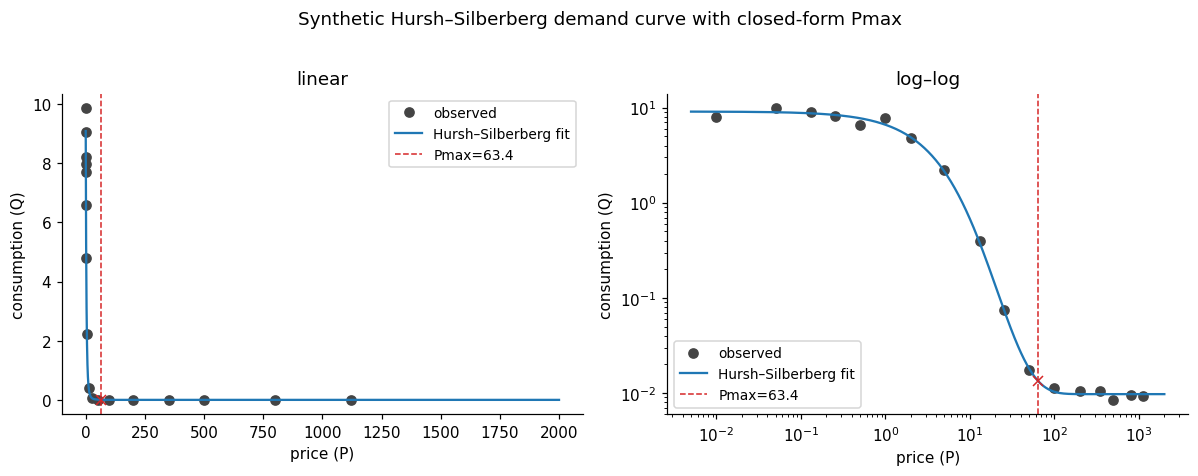

Pmax = 63.387    Omax = 0.859    EV = 37.166


In [3]:
P_grid = np.geomspace(0.005, 2000, 500)
Q_pred = hs.value(fit.params, P_grid)
derived = hs.derived(fit.params)
Q_at_pmax = float(hs.value(fit.params, np.array([derived.Pmax]))[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, log in zip(axes, [False, True]):
    ax.plot(P, Q_obs, "o", label="observed", color="#444")
    ax.plot(P_grid, Q_pred, "-", label="Hursh–Silberberg fit", color="#1f77b4")
    ax.axvline(derived.Pmax, color="#d62728", lw=1, ls="--", label=f"Pmax={derived.Pmax:.1f}")
    ax.plot(derived.Pmax, Q_at_pmax, "x", color="#d62728")
    if log:
        ax.set_xscale("log"); ax.set_yscale("log"); ax.set_title("log–log")
    else:
        ax.set_title("linear")
    ax.set_xlabel("price (P)"); ax.set_ylabel("consumption (Q)")
    ax.legend(loc="best", fontsize=9)
fig.suptitle("Synthetic Hursh–Silberberg demand curve with closed-form Pmax", y=1.02)
fig.tight_layout()
plt.show()
print(f"Pmax = {derived.Pmax:.3f}    Omax = {derived.Omax:.3f}    EV = {derived.essential_value:.3f}")

## Hursh–Silberberg vs Koffarnus

For `Q > 0` the two forms are mathematically identical (the Koffarnus exponentiation is just the inverse of the original log-space parameterisation). The Koffarnus form is preferred because it admits zero consumption naturally; we'll use it as the default for new fits per CLAUDE.md §3.2.

In [4]:
ko = Koffarnus()
Q_hs = hs.value(true, P_grid)
Q_ko = ko.value(true, P_grid)
print("max abs difference HS - Koffarnus:", float(np.max(np.abs(Q_hs - Q_ko))))

# Demonstrate the Koffarnus advantage: a regime that drives Q to zero.
true_zero = {"Q0": 10.0, "alpha": 0.05, "k": 3.0}
Q_dense = ko.value(true_zero, P)
Q_with_zero = Q_dense.copy()
Q_with_zero[Q_with_zero < 1e-3] = 0.0
fit_ko = ko.fit(P, Q_with_zero)
print("Koffarnus fit on data containing zeros:")
for k, v in fit_ko.params.items():
    print(f"  {k}: true={true_zero[k]:.4f}  fit={v:.4f}")

max abs difference HS - Koffarnus: 1.7763568394002505e-15
Koffarnus fit on data containing zeros:
  Q0: true=10.0000  fit=10.0000
  alpha: true=0.0500  fit=0.0500
  k: true=3.0000  fit=3.0000


## Sanity check: derivative consistency

The analytic derivative `dQ/dP` should match a centred finite-difference estimate. Useful for the Phase 2 unified model where we'll need autodiff-style elasticity computations.

In [5]:
P_check = np.array([0.5, 5.0, 50.0])
h = 1e-6
fd = (hs.value(true, P_check + h) - hs.value(true, P_check - h)) / (2 * h)
an = hs.derivative(true, P_check)
for p, a, f in zip(P_check, an, fd, strict=True):
    print(f"  P={p:>6.2f}: analytic={a: .6e}  fd={f: .6e}")

  P=  0.50: analytic=-2.840399e+00  fd=-2.840399e+00
  P=  5.00: analytic=-5.836274e-01  fd=-5.836274e-01
  P= 50.00: analytic=-4.998339e-04  fd=-4.998339e-04
